In [ ]:
# t-distributed Stochastic Neighbor Embedding
# Its main purpose is to take high-dimensional data and create a 2D or 3D representation making the structure of the data easier to visualize.
# it tries to preserve local relationships:

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [4]:
data = load_breast_cancer()

x = pd.DataFrame(data. data , columns=data.feature_names)

y= pd.Series(data.target)
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
#satndardized the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [8]:
#Apply t-SNE
tsne = TSNE (
    n_components = 2,
    perplexity = 30,
    learning_rate = "auto",
    max_iter = 1000,
    random_state = 42
)
x_tsne = tsne.fit_transform(x_scaled)


#perplexity: he number of neighboring points that
#t-SNE considers when constructing its local structure.

In [23]:
#create a dataframe
tsne_df = pd.DataFrame(x_tsne ,columns =["t-SNE 1" , "t-SNE 2"])
tsne_df.head()

,t-SNE 1,t-SNE 2
0,19.249428,-5.786858
1,15.891644,2.345365
2,18.455891,-2.464721
3,8.980064,-1.311632
4,19.763018,3.144620


In [24]:
tsne_df["target "] = y.values

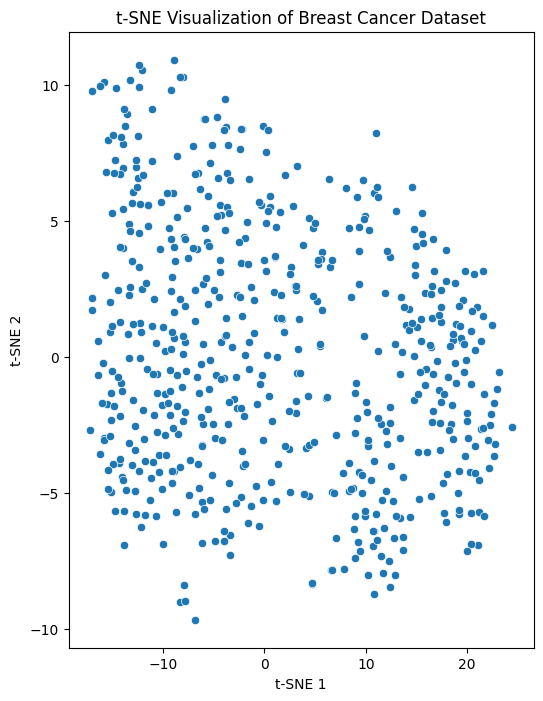

In [25]:
#visualize t-SNE
plt.figure(figsize = (6,8))

sns.scatterplot(data = tsne_df , x="t-SNE 1" , y="t-SNE 2")

plt.title("t-SNE Visualization of Breast Cancer Dataset")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.show()

In [31]:
# What happens for different perplexity?

tsne_results = {}

for i in [ 5, 10, 30 , 50]:
  tsne = TSNE(
      n_components = 2,
      perplexity = i,
      learning_rate ="auto",
      max_iter = 1000,
      random_state = 42

  )

  x_tsne = tsne.fit_transform(x_scaled)
  tsne_results[i] = x_tsne